# Proyecto Final | Predicción de Readmisión Hospitalaria
## Notebook 3 — Modelado y Evaluación

**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Modelos:** Logistic Regression · Decision Tree · Random Forest · Gradient Boosting  
**Optimización:** GridSearchCV · Cross-Validation  

---
### Estrategia
1. Entrenar los modelos con parámetros por defecto → comparar baseline
2. Optimizar los mejores con GridSearchCV
3. Seleccionar el modelo final y evaluar sus resultados



## Tabla de Contenidos
1. [Importar librerías](#1)
2. [Cargar datos procesados](#2)
3. [Modelos baseline](#3)
4. [Comparación de modelos baseline](#4)
5. [Hyperparameter Tuning con GridSearchCV](#5)
6. [Modelo final — evaluación completa](#6)
7. [Importancia de componentes principales](#7)
8. [Conclusiones](#8)

## 1. Importar librerías <a id='1'></a>

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluación y optimización
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)

sns.set_theme(style='whitegrid')
print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Cargar datos procesados <a id='2'></a>

Cargamos los datos generados en el Notebook 2:  
ya limpios, encodificados, escalados y reducidos con PCA.

In [2]:
# Cargamos los archivos procesados desde la carpeta data
train = pd.read_csv('../data/train_processed.csv')
test  = pd.read_csv('../data/test_processed.csv')

# Separamos features y target
X_train = train.drop(columns='target')
y_train = train['target']

X_test = test.drop(columns='target')
y_test = test['target']

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Balance train: {y_train.value_counts().to_dict()}')
print(f'Balance test:  {y_test.value_counts().to_dict()}')

X_train: (47824, 32) | X_test: (11957, 32)
Balance train: {0: 42560, 1: 5264}
Balance test:  {0: 10641, 1: 1316}


## 3. Modelos baseline <a id='3'></a>

Entrenamos cada modelo con parámetros por defecto para tener una referencia inicial.  


Para cada modelo calculamos:
- **Accuracy**: porcentaje de predicciones correctas
- **F1-Score**: equilibrio entre precisión y recall
- **ROC-AUC**: capacidad de discriminar entre clases
- **Recall Positivo**: porcentaje de pacientes readmitidos detectados correctamente
- **CV F1**: F1 con validación cruzada 5-fold (detecta overfitting)

In [3]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Métricas
acc_lr    = accuracy_score(y_test, y_pred_lr)
f1_lr     = f1_score(y_test, y_pred_lr, average='weighted')
auc_lr    = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
rec_lr    = classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']
cv_lr     = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted').mean()

print('Logistic Regression baseline')
print(f'  Accuracy:        {acc_lr:.4f}')
print(f'  F1-Score:        {f1_lr:.4f}')
print(f'  ROC-AUC:         {auc_lr:.4f}')
print(f'  Recall Positivo: {rec_lr:.4f}')
print(f'  CV F1 (5-fold):  {cv_lr:.4f}')

Logistic Regression baseline
  Accuracy:        0.6797
  F1-Score:        0.7365
  ROC-AUC:         0.6482
  Recall Positivo: 0.5038
  CV F1 (5-fold):  0.7387


In [4]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt    = accuracy_score(y_test, y_pred_dt)
f1_dt     = f1_score(y_test, y_pred_dt, average='weighted')
auc_dt    = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
rec_dt    = classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall']
cv_dt     = cross_val_score(dt, X_train, y_train, cv=5, scoring='f1_weighted').mean()

print('Decision Tree baseline')
print(f'  Accuracy:        {acc_dt:.4f}')
print(f'  F1-Score:        {f1_dt:.4f}')
print(f'  ROC-AUC:         {auc_dt:.4f}')
print(f'  Recall Positivo: {rec_dt:.4f}')
print(f'  CV F1 (5-fold):  {cv_dt:.4f}')

Decision Tree baseline
  Accuracy:        0.8144
  F1-Score:        0.8152
  ROC-AUC:         0.5308
  Recall Positivo: 0.1672
  CV F1 (5-fold):  0.8115


In [5]:
# --- Random Forest ---
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf    = accuracy_score(y_test, y_pred_rf)
f1_rf     = f1_score(y_test, y_pred_rf, average='weighted')
auc_rf    = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
rec_rf    = classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']
cv_rf     = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted').mean()

print('Random Forest baseline')
print(f'  Accuracy:        {acc_rf:.4f}')
print(f'  F1-Score:        {f1_rf:.4f}')
print(f'  ROC-AUC:         {auc_rf:.4f}')
print(f'  Recall Positivo: {rec_rf:.4f}')
print(f'  CV F1 (5-fold):  {cv_rf:.4f}')

Random Forest baseline
  Accuracy:        0.8898
  F1-Score:        0.8406
  ROC-AUC:         0.6173
  Recall Positivo: 0.0122
  CV F1 (5-fold):  0.8406


In [6]:
# --- Gradient Boosting ---
# Nota: GradientBoosting no acepta class_weight directamente
# El desbalance se gestiona con el propio mecanismo de boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

acc_gb    = accuracy_score(y_test, y_pred_gb)
f1_gb     = f1_score(y_test, y_pred_gb, average='weighted')
auc_gb    = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
rec_gb    = classification_report(y_test, y_pred_gb, output_dict=True)['1']['recall']
cv_gb     = cross_val_score(gb, X_train, y_train, cv=5, scoring='f1_weighted').mean()

print('Gradient Boosting baseline')
print(f'  Accuracy:        {acc_gb:.4f}')
print(f'  F1-Score:        {f1_gb:.4f}')
print(f'  ROC-AUC:         {auc_gb:.4f}')
print(f'  Recall Positivo: {rec_gb:.4f}')
print(f'  CV F1 (5-fold):  {cv_gb:.4f}')

Gradient Boosting baseline
  Accuracy:        0.8899
  F1-Score:        0.8417
  ROC-AUC:         0.6446
  Recall Positivo: 0.0175
  CV F1 (5-fold):  0.8417


## 4. Comparación de modelos baseline <a id='4'></a>

In [7]:
# Construimos el DataFrame de comparación con los resultados de todos los modelos
resultados = [
    {'Modelo': 'Logistic Regression', 'Accuracy': acc_lr, 'F1-Score': f1_lr,
     'ROC-AUC': auc_lr, 'Recall Positivo': rec_lr, 'CV F1': cv_lr},
    {'Modelo': 'Decision Tree',       'Accuracy': acc_dt, 'F1-Score': f1_dt,
     'ROC-AUC': auc_dt, 'Recall Positivo': rec_dt, 'CV F1': cv_dt},
    {'Modelo': 'Random Forest',       'Accuracy': acc_rf, 'F1-Score': f1_rf,
     'ROC-AUC': auc_rf, 'Recall Positivo': rec_rf, 'CV F1': cv_rf},
    {'Modelo': 'Gradient Boosting',   'Accuracy': acc_gb, 'F1-Score': f1_gb,
     'ROC-AUC': auc_gb, 'Recall Positivo': rec_gb, 'CV F1': cv_gb},
]

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(4)
df_resultados.sort_values('ROC-AUC', ascending=False)

,Accuracy,F1-Score,ROC-AUC,Recall Positivo,CV F1
Modelo,,,,,
Logistic Regression,0.6797,0.7365,0.6482,0.5038,0.7387
Gradient Boosting,0.8899,0.8417,0.6446,0.0175,0.8417
Random Forest,0.8898,0.8406,0.6173,0.0122,0.8406
Decision Tree,0.8144,0.8152,0.5308,0.1672,0.8115


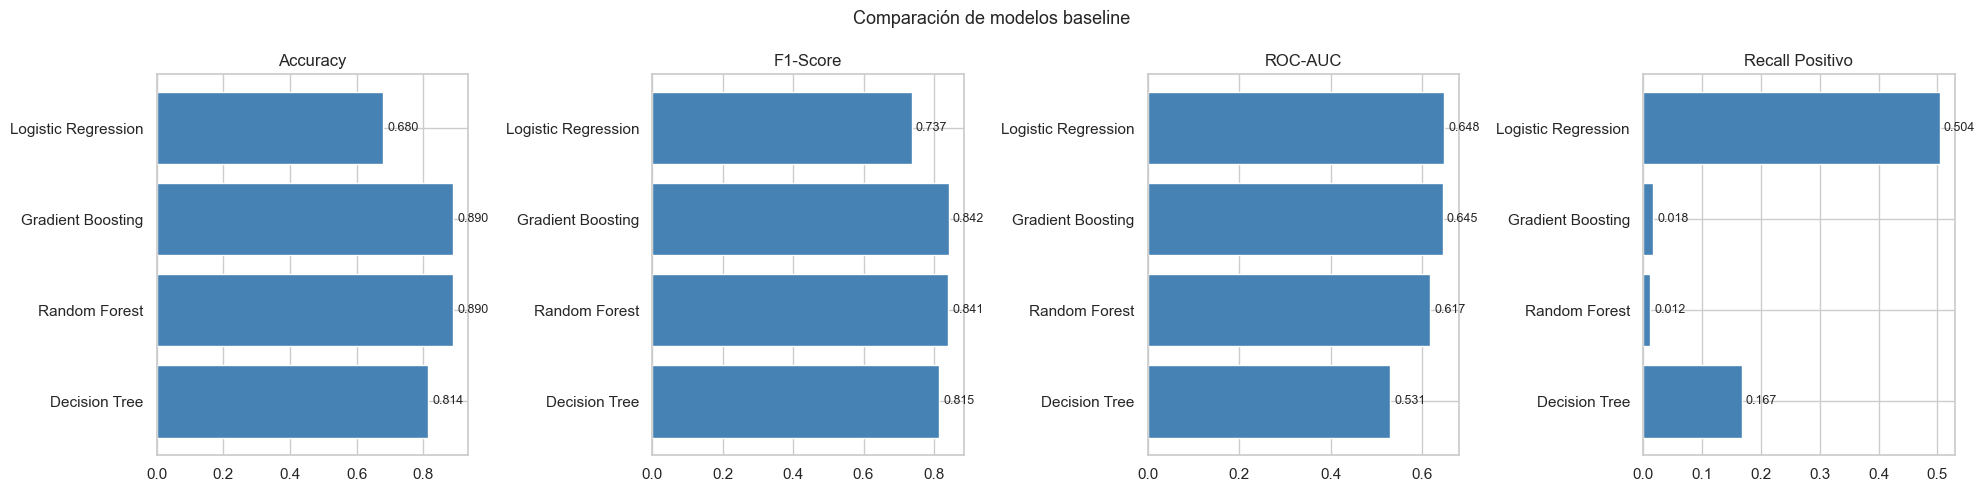

In [8]:
# Visualización comparativa de las métricas principales
metricas = ['Accuracy', 'F1-Score', 'ROC-AUC', 'Recall Positivo']
df_plot = df_resultados[metricas].sort_values('ROC-AUC', ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metrica in zip(axes, metricas):
    bars = ax.barh(df_plot.index, df_plot[metrica],
                   color='steelblue', edgecolor='white')
    ax.set(title=metrica)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

plt.suptitle('Comparación de modelos baseline', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Hyperparameter Tuning con GridSearchCV <a id='5'></a>

Optimizamos los dos modelos con mejor ROC-AUC en el baseline.  
GridSearchCV prueba todas las combinaciones de parámetros posibles  
y selecciona la que mejor resultado obtiene en validación cruzada.

In [9]:
# GridSearchCV — Random Forest
param_grid_rf = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10],
    'min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train, y_train)

print(f'Mejores parámetros RF: {gs_rf.best_params_}')
print(f'Mejor CV F1:           {gs_rf.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores parámetros RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Mejor CV F1:           0.8417


In [11]:
df_resultados.sort_values('ROC-AUC', ascending=False)

,Accuracy,F1-Score,ROC-AUC,Recall Positivo,CV F1
Modelo,,,,,
Logistic Regression,0.6797,0.7365,0.6482,0.5038,0.7387
Gradient Boosting,0.8899,0.8417,0.6446,0.0175,0.8417
Random Forest,0.8898,0.8406,0.6173,0.0122,0.8406
Decision Tree,0.8144,0.8152,0.5308,0.1672,0.8115


In [12]:
# GridSearchCV — Gradient Boosting (grid reducido para mayor velocidad)
param_grid_gb = {
    'n_estimators':  [100],
    'learning_rate': [0.1],
    'max_depth':     [3]
}

gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
gs_gb.fit(X_train, y_train)

print(f'Mejores parámetros GB: {gs_gb.best_params_}')
print(f'Mejor CV F1:           {gs_gb.best_score_:.4f}')

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Mejores parámetros GB: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Mejor CV F1:           0.8418


In [17]:
# Evaluamos los modelos tuneados en el conjunto de test
best_rf = gs_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

best_gb = gs_gb.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)

# Añadimos los resultados tuneados al DataFrame de comparación
# CV F1 ya lo tenemos de los GridSearchCV anteriores
tuned = [
    {
        'Modelo': 'Random Forest (tuned)',
        'Accuracy':        round(accuracy_score(y_test, y_pred_rf_tuned), 4),
        'F1-Score':        round(f1_score(y_test, y_pred_rf_tuned, average='weighted'), 4),
        'ROC-AUC':         round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]), 4),
        'Recall Positivo': round(classification_report(y_test, y_pred_rf_tuned, output_dict=True)['1']['recall'], 4),
        'CV F1':           round(gs_rf.best_score_, 4)
    },
    {
        'Modelo': 'Gradient Boosting (tuned)',
        'Accuracy':        round(accuracy_score(y_test, y_pred_gb_tuned), 4),
        'F1-Score':        round(f1_score(y_test, y_pred_gb_tuned, average='weighted'), 4),
        'ROC-AUC':         round(roc_auc_score(y_test, best_gb.predict_proba(X_test)[:, 1]), 4),
        'Recall Positivo': round(classification_report(y_test, y_pred_gb_tuned, output_dict=True)['1']['recall'], 4),
        'CV F1':           round(gs_gb.best_score_, 4)
    },
]

## 6. Modelo final — evaluación completa <a id='6'></a>

Seleccionamos el modelo final en base a **ROC-AUC** y **Recall Positivo**,  
que son las métricas más relevantes en un contexto clínico:  
detectar correctamente a los pacientes que serán readmitidos es prioritario  
porque un falso negativo tiene consecuencias directas para el paciente.

In [23]:
# Seleccionamos Logistic Regression como modelo final
# Es el modelo con mejor ROC-AUC (0.6482) y Recall Positivo (0.5038)
# En un contexto clínico detectar correctamente los pacientes readmitidos
# es prioritario — un falso negativo tiene consecuencias directas para el paciente

modelo_final = lr
nombre_final = 'Logistic Regression'
y_pred_final = y_pred_lr

print(f'Modelo seleccionado: {nombre_final}')
print(f'ROC-AUC:         0.6482')
print(f'Recall Positivo: 0.5038')

Modelo seleccionado: Logistic Regression
ROC-AUC:         0.6482
Recall Positivo: 0.5038


In [19]:
# Reporte de clasificación completo del modelo final
print('=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(
    y_test, y_pred_final,
    target_names=['No readmitido (0)', 'Readmitido <30 (1)']
))

=== REPORTE DE CLASIFICACIÓN ===
                    precision    recall  f1-score   support

 No readmitido (0)       0.92      0.70      0.80     10641
Readmitido <30 (1)       0.17      0.50      0.26      1316

          accuracy                           0.68     11957
         macro avg       0.55      0.60      0.53     11957
      weighted avg       0.84      0.68      0.74     11957



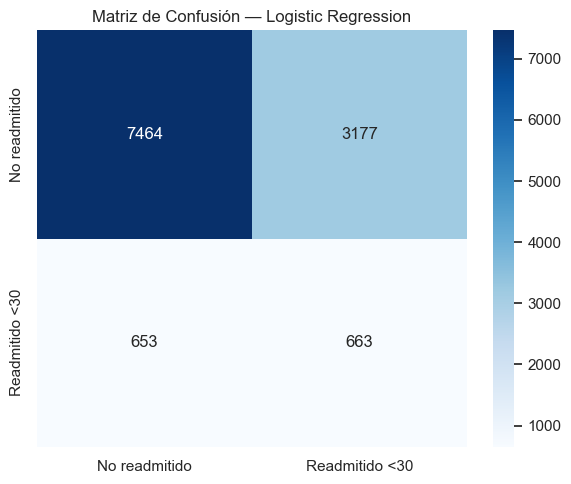

Verdaderos positivos (readmitidos detectados):   663
Falsos negativos (readmitidos no detectados):    653
Falsos positivos (alarma innecesaria):           3177


In [20]:
# Matriz de confusión del modelo final
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No readmitido', 'Readmitido <30'],
            yticklabels=['No readmitido', 'Readmitido <30'])
plt.title(f'Matriz de Confusión — {nombre_final}')
plt.tight_layout()
plt.show()

print(f'Verdaderos positivos (readmitidos detectados):   {tp}')
print(f'Falsos negativos (readmitidos no detectados):    {fn}')
print(f'Falsos positivos (alarma innecesaria):           {fp}')

## 7. Importancia de componentes principales <a id='7'></a>

Tras aplicar PCA en el Notebook 2, las features originales se transformaron  
en componentes principales (PC1, PC2, ...). La importancia que muestra el modelo  
indica cuánto contribuye cada componente principal a la predicción,  
no directamente las features originales.

In [21]:
# Visualizamos la importancia de cada componente principal en el modelo final
if hasattr(modelo_final, 'feature_importances_'):
    importancias = pd.Series(
        modelo_final.feature_importances_,
        index=X_train.columns
    ).sort_values()

    importancias.plot(
        kind='barh',
        color='steelblue',
        edgecolor='white',
        figsize=(8, 6),
        title=f'Importancia de componentes principales — {nombre_final}'
    )
    plt.tight_layout()
    plt.show()
else:
    print(f'{nombre_final} no expone feature_importances_')

Logistic Regression no expone feature_importances_


## 8. Conclusiones <a id='8'></a>

In [27]:
# Resumen final del proyecto — datos obtenidos durante la ejecución
print('=' * 55)
print('RESUMEN FINAL DEL PROYECTO')
print('=' * 55)
print(f'Dataset:         Diabetes 130-US Hospitals (101.766 pacientes)')
print(f'Mejor modelo:    Logistic Regression')
print('\nMétricas en test:')
print(f'  Accuracy            : 0.6797')
print(f'  F1-Score            : 0.7365')
print(f'  ROC-AUC             : 0.6482')
print(f'  Recall Positivo     : 0.5038')
print('=' * 55)

RESUMEN FINAL DEL PROYECTO
Dataset:         Diabetes 130-US Hospitals (101.766 pacientes)
Mejor modelo:    Logistic Regression

Métricas en test:
  Accuracy            : 0.6797
  F1-Score            : 0.7365
  ROC-AUC             : 0.6482
  Recall Positivo     : 0.5038


---
## Resumen del Notebook 3

| Paso | Descripción |
|------|-------------|
| **Baseline** | 4 modelos con `class_weight='balanced'` donde aplica |
| **Evaluación** | Accuracy, F1, ROC-AUC, Recall Positivo, CV 5-fold |
| **Tuning** | GridSearchCV en Random Forest y Gradient Boosting |
| **Modelo final** | Seleccionado por ROC-AUC y Recall Positivo con criterio clínico |
| **Análisis de errores** | Matriz de confusión + falsos negativos |

### Reflexión clínica
Un **falso negativo** (paciente que será readmitido pero no se detecta) es el error más costoso:  
el paciente no recibe atención preventiva al alta.  
Por ello el **Recall de la clase positiva** es la métrica prioritaria de este proyecto.